In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
# Imports & load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix


file_path = '/content/drive/MyDrive/MRP/price_preprocessed.csv'

price_df = pd.read_csv(file_path, parse_dates=['date'])
price_df = price_df.sort_values(['symbol', 'date']).reset_index(drop=True)

In [4]:
price_df.head(), price_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11083232 entries, 0 to 11083231
Data columns (total 8 columns):
 #   Column     Dtype         
---  ------     -----         
 0   date       datetime64[ns]
 1   volume     float64       
 2   open       float64       
 3   high       float64       
 4   low        float64       
 5   close      float64       
 6   adj close  float64       
 7   symbol     object        
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 676.5+ MB


(        date    volume      open      high       low     close  adj close  \
 0 2016-01-04  0.002927  0.004108  0.002234  0.004037  0.002770   0.002661   
 1 2016-01-05  0.002304  0.004075  0.002221  0.004037  0.002761   0.002652   
 2 2016-01-06  0.001873  0.004026  0.002223  0.004008  0.002773   0.002664   
 3 2016-01-07  0.003120  0.004016  0.002178  0.003883  0.002655   0.002551   
 4 2016-01-08  0.003327  0.003924  0.002154  0.003849  0.002627   0.002524   
 
   symbol  
 0      A  
 1      A  
 2      A  
 3      A  
 4      A  ,
 None)

In [5]:
# Missingness & Summary Stats
print("Missing values per column:\n", price_df.isnull().sum())
price_df.describe()

Missing values per column:
 date         0
volume       0
open         0
high         0
low          0
close        0
adj close    0
symbol       0
dtype: int64


,date,volume,open,high,low,close,adj close
count,11083232,1.108323e+07,1.108323e+07,1.108323e+07,1.108323e+07,1.108323e+07,1.108323e+07
mean,2019-09-24 04:57:50.892533504,9.972198e-04,5.140682e-03,2.829213e-03,5.060211e-03,3.496372e-03,3.389597e-03
min,2016-01-04 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2017-11-24 00:00:00,1.780939e-05,1.167467e-03,6.432542e-04,1.147737e-03,7.938723e-04,7.325957e-04
50%,2019-08-01 00:00:00,1.170077e-04,2.522009e-03,1.377627e-03,2.503207e-03,1.716425e-03,1.612255e-03
75%,2021-07-08 00:00:00,5.726608e-04,4.969988e-03,2.715661e-03,4.923161e-03,3.381787e-03,3.231113e-03
max,2023-12-28 00:00:00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
std,NaN,4.577394e-03,1.998391e-02,1.113282e-02,1.941853e-02,1.358739e-02,1.354313e-02


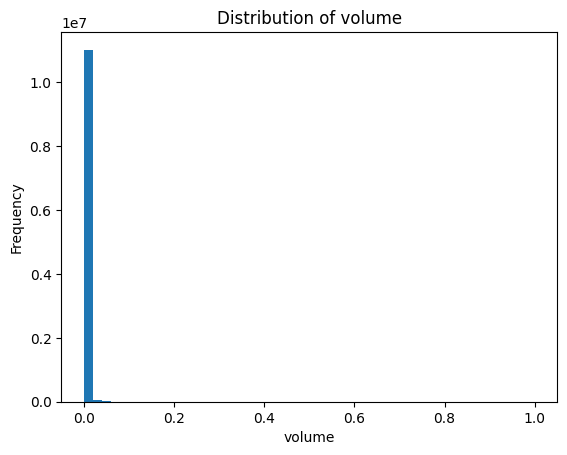

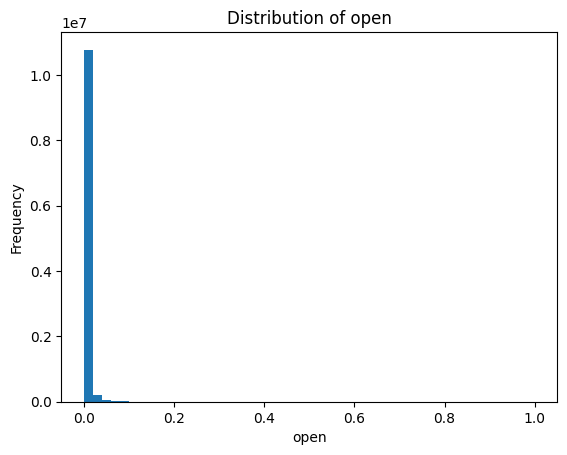

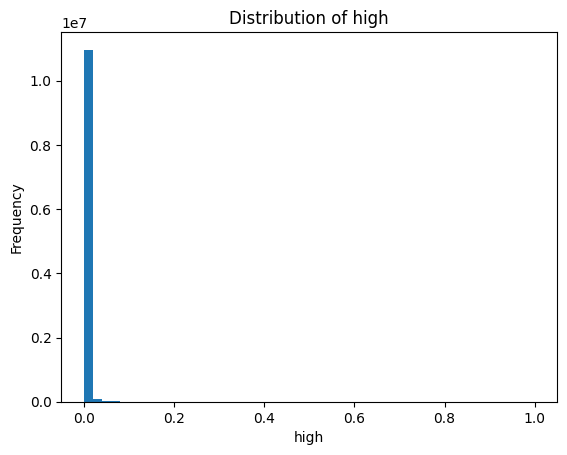

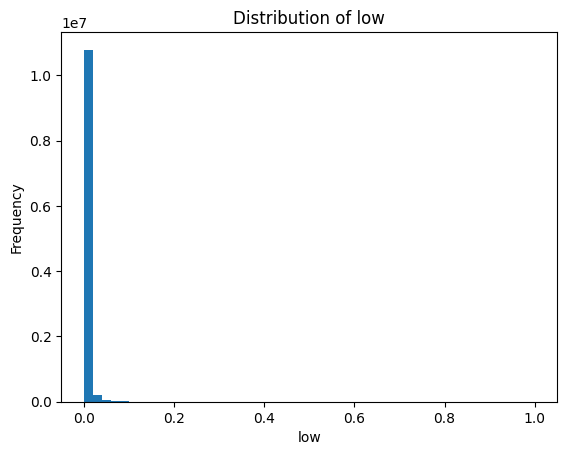

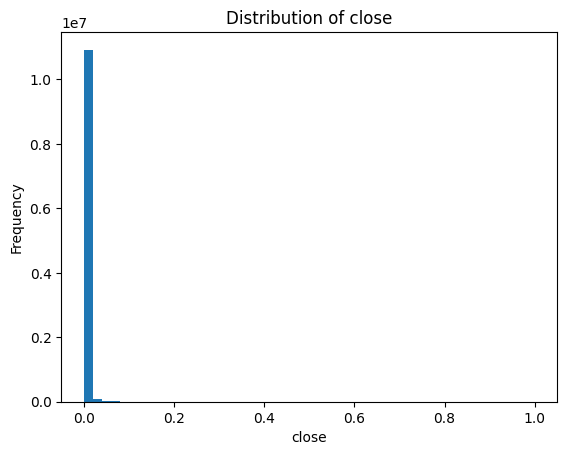

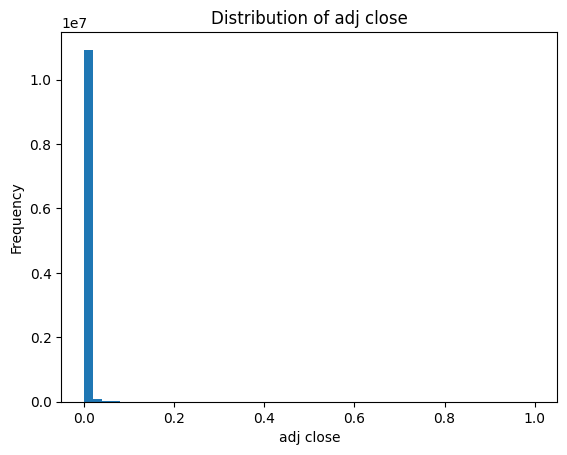

In [6]:
# Feature Distributions
for col in ['volume','open','high','low','close','adj close']:
    plt.figure()
    plt.hist(price_df[col], bins=50)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


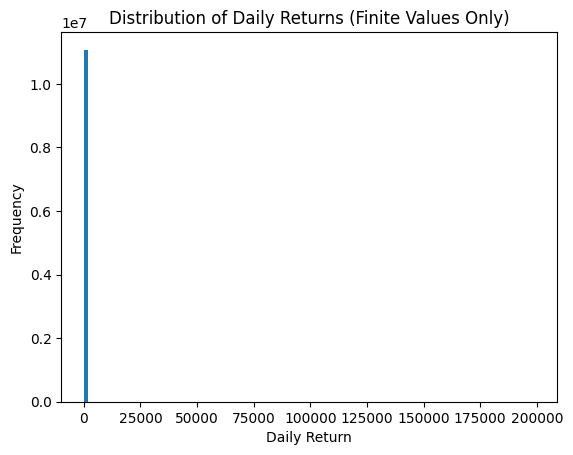

,return
count,1.107575e+07
mean,3.500107e-01
std,1.273029e+02
min,-1.000000e+00
25%,-9.351474e-03
50%,0.000000e+00
75%,9.435209e-03
max,1.990830e+05


In [8]:
# Returns Analysis (fixed)
import numpy as np

# Compute returns
price_df['return'] = price_df.groupby('symbol')['close'].pct_change()

# Remove infinite and missing values
returns = price_df['return'].replace([np.inf, -np.inf], np.nan).dropna()

# Plot distribution
plt.figure()
plt.hist(returns, bins=100)
plt.title('Distribution of Daily Returns (Finite Values Only)')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

# Summary statistics
returns.describe()


#What we did:
#	1.	Replaced any +-∞ with NaN
#	2.	Dropped those NaNs
#	3.	Plotted only the finite returns

# This will give us a valid histogram and accurate descriptive stats without the “range not finite” error.

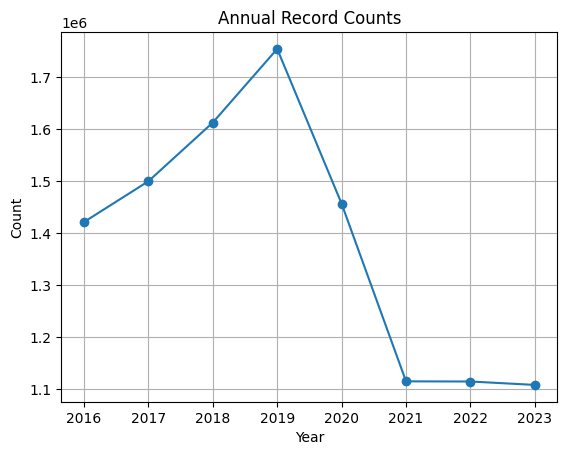

In [9]:
# Temporal Trends
price_df['year'] = price_df['date'].dt.year
annual_counts = price_df.groupby('year').size()
plt.figure()
plt.plot(annual_counts.index, annual_counts.values, marker='o')
plt.title('Annual Record Counts')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid(True)
plt.show()

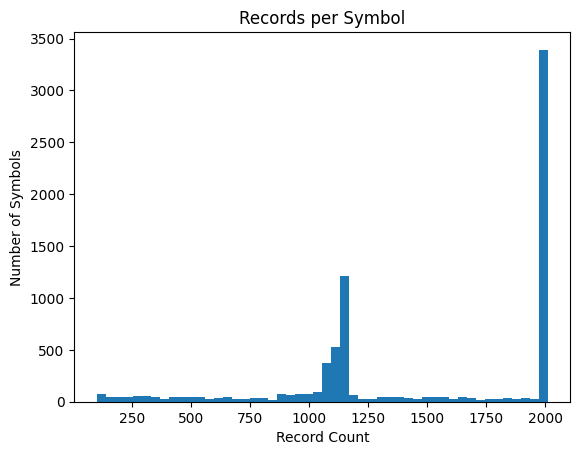

,count
symbol,
AAME,2011
zumz,2011
A,2011
AA,2011
AAOI,2011
AACG,2011
AADR,2011
xpp,2011
xtnt,2011


In [10]:
# Symbol Coverage
symbol_counts = price_df['symbol'].value_counts()
plt.figure()
plt.hist(symbol_counts, bins=50)
plt.title('Records per Symbol')
plt.xlabel('Record Count')
plt.ylabel('Number of Symbols')
plt.show()
symbol_counts.head(10)

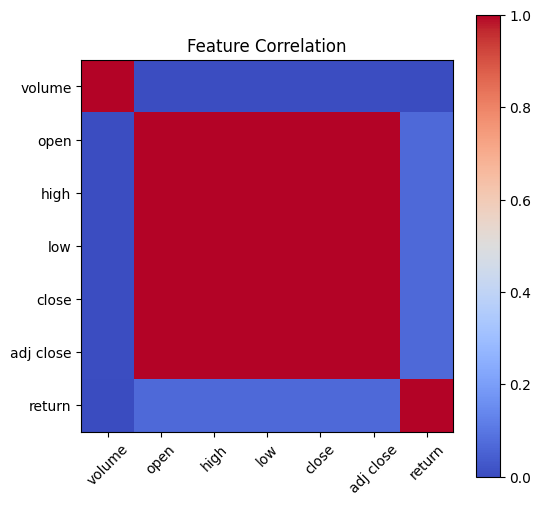

In [11]:
# Correlation Heatmap
corr = price_df[['volume','open','high','low','close','adj close','return']].corr()
plt.figure(figsize=(6,6))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.title('Feature Correlation')
plt.show()

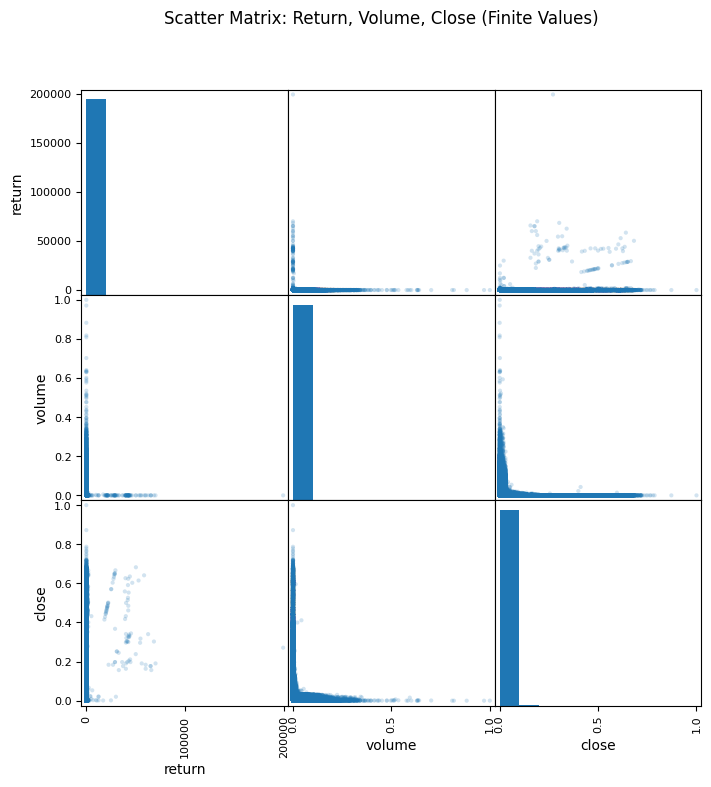

In [13]:
# Scatter Matrix (filtered)
import numpy as np
from pandas.plotting import scatter_matrix

# Compute return (if not already done)
price_df['return'] = price_df.groupby('symbol')['close'].pct_change()

# Filter to finite values only
filtered = price_df[['return', 'volume', 'close']].replace([np.inf, -np.inf], np.nan).dropna()

# Scatter matrix
scatter_matrix(filtered, alpha=0.2, figsize=(8, 8), diagonal='hist')
plt.suptitle('Scatter Matrix: Return, Volume, Close (Finite Values)')
plt.show()

# This will remove any rows where return is infinite (or NaN) and allow the scatter matrix to render properly.

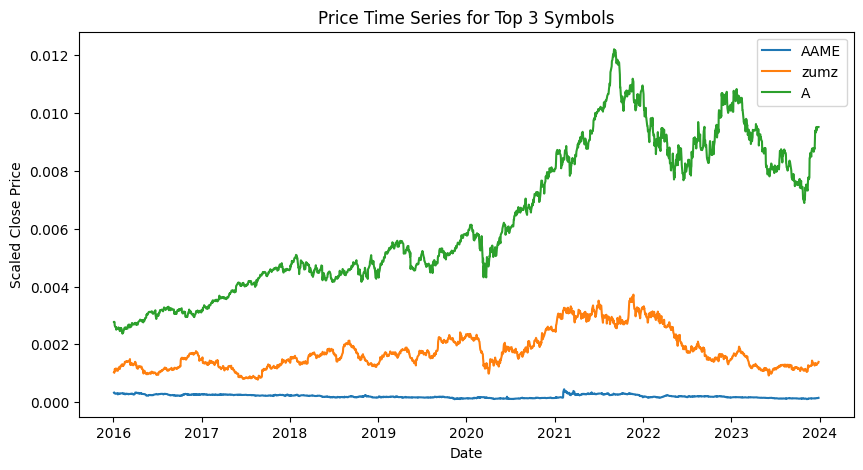

In [14]:
# Sample Time Series
top_syms = symbol_counts.head(3).index.tolist()
plt.figure(figsize=(10,5))
for s in top_syms:
    subset = price_df[price_df['symbol']==s]
    plt.plot(subset['date'], subset['close'], label=s)
plt.title('Price Time Series for Top 3 Symbols')
plt.xlabel('Date')
plt.ylabel('Scaled Close Price')
plt.legend()
plt.show()


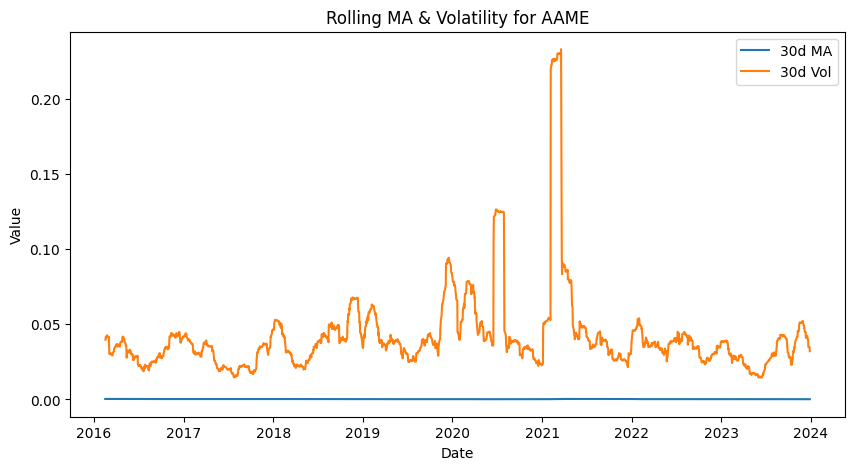

In [15]:
# Rolling Stats for One Symbol
sym = top_syms[0]
df_sym = price_df[price_df['symbol']==sym].copy()
df_sym['ma30'] = df_sym['close'].rolling(30).mean()
df_sym['vol30'] = df_sym['return'].rolling(30).std()
plt.figure(figsize=(10,5))
plt.plot(df_sym['date'], df_sym['ma30'], label='30d MA')
plt.plot(df_sym['date'], df_sym['vol30'], label='30d Vol')
plt.title(f'Rolling MA & Volatility for {sym}')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()